***Introduction***

*The COVID-19 pandemic highlighted significant differences in how countries around the world managed large-scale health crises. While some nations were able to control the spread effectively, others faced severe impacts due to differences in healthcare infrastructure and preparedness.*

***Objective***

*To analyze pandemic trends and healthcare system capacity across countries to understand how preparedness factors influence pandemic outcomes such as cases, deaths, and recovery.*

***Problem Statement***

*Countries experienced different levels of pandemic impact due to variations in healthcare infrastructure. This project aims to identify how healthcare capacity factors like ICU beds, hospital availability, vaccination rates, and testing rates affect pandemic outcomes across countries.*

***Overview***

*This project analyzes pandemic and healthcare datasets using Python,OOP,  Pandas, Matplotlib, and Seaborn to identify patterns between healthcare preparedness and pandemic impact through data cleaning, EDA, and cross-dataset analysis.*

**Import** **Libraries**

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

**Data Loading using OOP**

In [3]:
#------(DataLoader class)-----------#

class DataLoader:

  def __init__(self,file_path):
    self.file_path =  file_path
    self.df= None

  def load(self):
    self.df =pd.read_csv(self.file_path)
    return self.df

  def info(self):
    return self.df.info()

  def describe(self):
    return self.df.describe()

  def preview(self):
    return self.df.head()

In [4]:
# ----- object created ----
loader1 = DataLoader("/content/pandemic_country_statistics.csv")
pandemic = loader1.load()

loader2 = DataLoader("/content/global_healthcare_system_metrics.csv")
healthcare = loader2.load()

In [5]:
# ----- Pandemic Dataset ----
pandemic

,country,report_date,total_cases,total_deaths,total_recovered,cases_per_million,deaths_per_million,population,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,USA,29-02-2020,111820082,1219487,109814428.0,333985,3642,334805269,NaN,NaN,NaN
1,India,29-02-2020,45035393,533570,NaN,32016,379,1406631776,NaN,NaN,NaN
2,France,29-02-2020,40138560,167642,39970918.0,612013,2556,65584518,NaN,NaN,NaN
3,Germany,29-02-2020,38828995,183027,38240600.0,462891,2182,83883596,NaN,NaN,NaN
4,Brazil,29-02-2020,38743918,711380,36249161.0,179908,3303,215353593,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
62,Ecuador,29-02-2020,1070188,36043,1034145.0,59083,1990,18113361,NaN,NaN,NaN
63,UAE,29-02-2020,1067030,2349,NaN,105837,233,10081785,NaN,NaN,NaN
64,Panama,29-02-2020,1059893,8727,1051102.0,238341,1962,4446964,NaN,NaN,NaN
65,Uruguay,29-02-2020,1041111,7664,1030944.0,297799,2192,3496016,NaN,NaN,NaN


In [ ]:
# ----- Healthcare Dataset ----
healthcare

,country,report_date,Vaccination_Rate,Testing_Rate,Hospital_Beds_per_1000,ICU_Capacity_Index,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,USA,29-02-2020,65.4,2200,2.8,7.1,NaN,NaN,NaN
1,India,29-02-2020,59.7,850,0.5,6.4,NaN,NaN,NaN
2,France,29-02-2020,78.1,2100,5.9,8.2,NaN,NaN,NaN
3,Germany,29-02-2020,76.5,2050,8.0,8.5,NaN,NaN,NaN
4,Brazil,29-02-2020,70.3,1100,2.2,6.9,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
62,Ecuador,29-02-2020,67.0,1200,1.5,6.8,NaN,NaN,NaN
63,UAE,29-02-2020,83.5,2700,1.2,8.5,NaN,NaN,NaN
64,Panama,29-02-2020,71.5,1500,2.2,7.3,NaN,NaN,NaN
65,Uruguay,29-02-2020,80.0,1900,2.8,8.0,NaN,NaN,NaN


**Dataset Cleaning using OOP**

In [ ]:
# ------ DataCleaner class ----------- #

class DataCleaner:

    def __init__(self, df):
        self.df = df

    def drop_unnamed_columns(self):
        self.df = self.df.loc[:, ~self.df.columns.str.contains("^Unnamed")]
        return self.df

    def standardize_columns(self):
        self.df.columns = (
            self.df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ", "_")
        )
        return self.df

    def handle_missing_values(self):
        self.df = self.df.dropna()
        return self.df

    def get_data(self):
        return self.df

In [ ]:
# ----- object created ----

clean1 = DataCleaner(pandemic)

pandemic = clean1.drop_unnamed_columns()
pandemic = clean1.standardize_columns()
pandemic = clean1.handle_missing_values()

clean2 = DataCleaner(healthcare)

healthcare = clean2.drop_unnamed_columns()
healthcare = clean2.standardize_columns()
healthcare = clean2.handle_missing_values()


In [ ]:
# --- Preview data
pandemic.head()

,country,report_date,total_cases,total_deaths,total_recovered,cases_per_million,deaths_per_million,population
0,USA,29-02-2020,111820082,1219487,109814428.0,333985,3642,334805269
2,France,29-02-2020,40138560,167642,39970918.0,612013,2556,65584518
3,Germany,29-02-2020,38828995,183027,38240600.0,462891,2182,83883596
4,Brazil,29-02-2020,38743918,711380,36249161.0,179908,3303,215353593
5,S. Korea,29-02-2020,34571873,35934,34535939.0,673523,700,51329899


In [ ]:
# --- Preview data
healthcare.head()

,country,report_date,vaccination_rate,testing_rate,hospital_beds_per_1000,icu_capacity_index
0,USA,29-02-2020,65.4,2200,2.8,7.1
1,India,29-02-2020,59.7,850,0.5,6.4
2,France,29-02-2020,78.1,2100,5.9,8.2
3,Germany,29-02-2020,76.5,2050,8.0,8.5
4,Brazil,29-02-2020,70.3,1100,2.2,6.9


In [ ]:
# --- Datatypes check
pandemic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56 entries, 0 to 66
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             56 non-null     object 
 1   report_date         56 non-null     object 
 2   total_cases         56 non-null     int64  
 3   total_deaths        56 non-null     int64  
 4   total_recovered     56 non-null     float64
 5   cases_per_million   56 non-null     int64  
 6   deaths_per_million  56 non-null     int64  
 7   population          56 non-null     int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 6.0+ KB


In [ ]:
# --- Datatypes check
healthcare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 67 non-null     object 
 1   report_date             67 non-null     object 
 2   vaccination_rate        67 non-null     float64
 3   testing_rate            67 non-null     int64  
 4   hospital_beds_per_1000  67 non-null     float64
 5   icu_capacity_index      67 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 3.3+ KB


In [ ]:
# --- Columns check
pandemic.columns

Index(['country', 'report_date', 'total_cases', 'total_deaths',
       'total_recovered', 'cases_per_million', 'deaths_per_million',
       'population'],
      dtype='object')

In [ ]:
# --- Columns check
pandemic.columns

Index(['country', 'report_date', 'total_cases', 'total_deaths',
       'total_recovered', 'cases_per_million', 'deaths_per_million',
       'population'],
      dtype='object')

In [ ]:
# --- Duplicate check
pandemic.duplicated().sum()

np.int64(0)

In [ ]:
# --- Duplicate check
healthcare.duplicated().sum()

np.int64(0)

📊***EDA & Visualization–> Pandemic Dataset***

🌍***Country Impact Analysis***

In [63]:
#1. Which countries have the highest total COVID-19 cases

highest_cases = pandemic.groupby("country")["total_cases"].sum().sort_values(ascending=False).head(10)

highest_cases

,total_cases
country,
USA,111820082
India,45035393
France,40138560
Germany,38828995
Brazil,38743918
S. Korea,34571873
Japan,33803572
Italy,26723249
UK,24910387


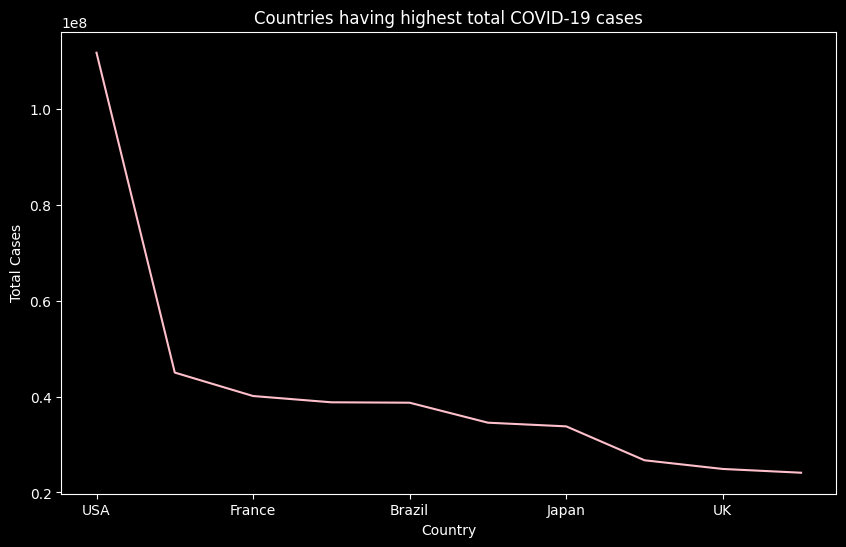

In [64]:
#----- Visualization -----

plt.style.use("dark_background")

highest_cases.plot(kind="line",
                   color="pink",
                   figsize=(10,6),

)

plt.title("Countries having highest total COVID-19 cases")
plt.xlabel("Country")
plt.ylabel("Total Cases")

plt.show()


USA has the highest total cases among all countries.

In [ ]:
# 2. Which countries experienced the highest number of deaths?

In [ ]:

death_cases = pandemic.groupby("country")["total_deaths"].sum().sort_values(ascending=False).head(10)

death_cases

,total_deaths
country,
USA,1219487
Brazil,711380
Russia,402756
Mexico,334958
UK,232112
Peru,222161
Italy,196487
Germany,183027
France,167642


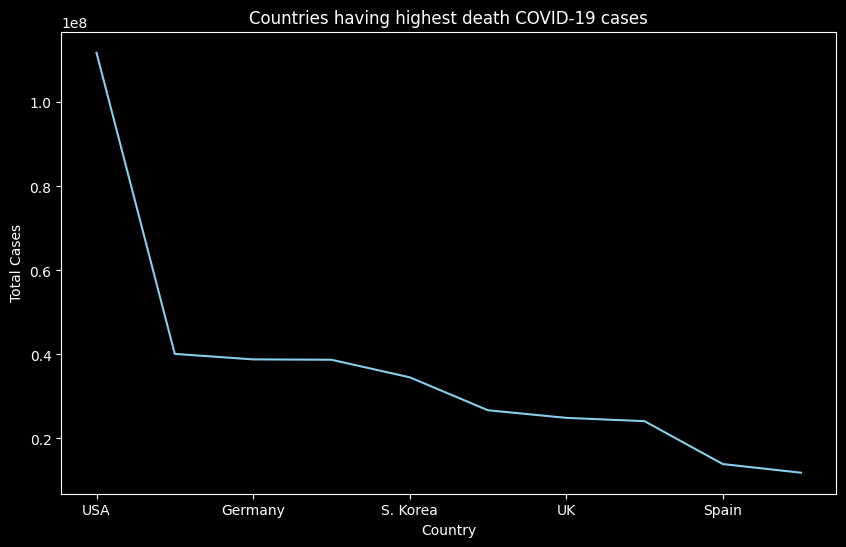

In [ ]:
# ----- Visualization -----

plt.style.use("dark_background")

highest_cases.plot(kind="line",
                   color="skyblue",
                   figsize=(10,6),

)
plt.title("Countries having highest death COVID-19 cases")
plt.xlabel("Country")
plt.ylabel("Total Cases")

plt.show()


USA has the highest total death cases among all countries.

In [ ]:
# 3. How does the severity of the pandemic vary across countries?

In [ ]:

severity = pandemic.groupby("country")[["total_cases", "total_deaths"]].sum()

severity["death_rate"] = severity["total_deaths"] / severity["total_cases"]

severity.sort_values("death_rate", ascending=False)

,total_cases,total_deaths,death_rate
country,,,
Peru,4572667,222161,0.048585
Mexico,7702809,334958,0.043485
Ecuador,1070188,36043,0.033679
Bulgaria,1339851,38748,0.028920
South Africa,4076463,102595,0.025168
Indonesia,6829221,162063,0.023731
Colombia,6400173,143200,0.022374
Hungary,2230232,49048,0.021992
Ukraine,5557995,112418,0.020226


Text(0, 0.5, 'Frequency')

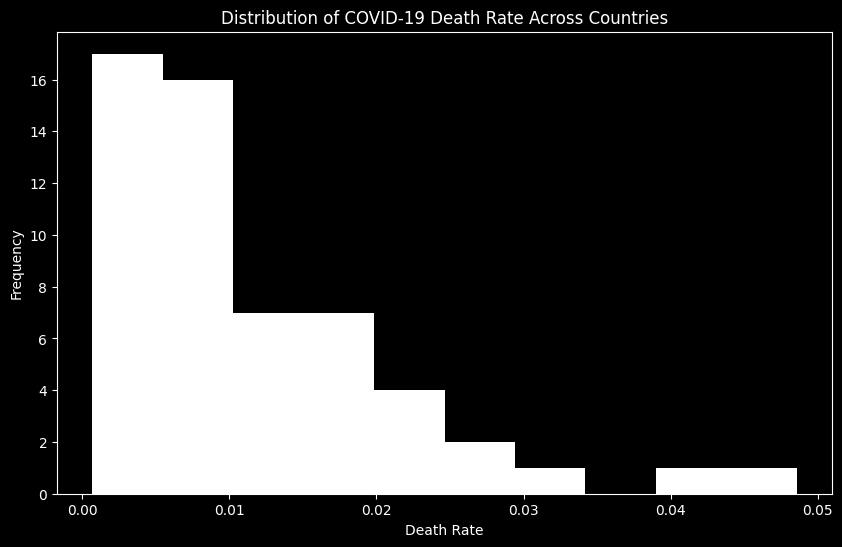

In [ ]:
# ---Visualization ---

severity["death_rate"].plot(kind="hist",
              color="white",
              figsize=(10,6))
plt.title("Distribution of COVID-19 Death Rate Across Countries")
plt.xlabel("Death Rate")
plt.ylabel("Frequency")

Most countries have low to moderate fatality rates.

In [ ]:
# 4. Which countries experienced the highest overall COVID-19 burden when considering both total cases and total deaths?

In [57]:
comparision = pandemic.groupby("country")[["total_cases","total_deaths"]].sum()

comparision["cases_rank"] = comparision["total_cases"].rank(ascending=False)
comparision["deaths_rank"] = comparision["total_deaths"].rank(ascending=False)

comparision["total_burden"] = comparision["cases_rank"] + comparision["deaths_rank"]
comparision = comparision.sort_values("total_burden")

comparision["total_burden"]

,total_burden
country,
USA,2.0
India,5.0
Brazil,7.0
Germany,13.0
France,13.0
...,...
Nepal,121.0
Cuba,123.0
Panama,125.0


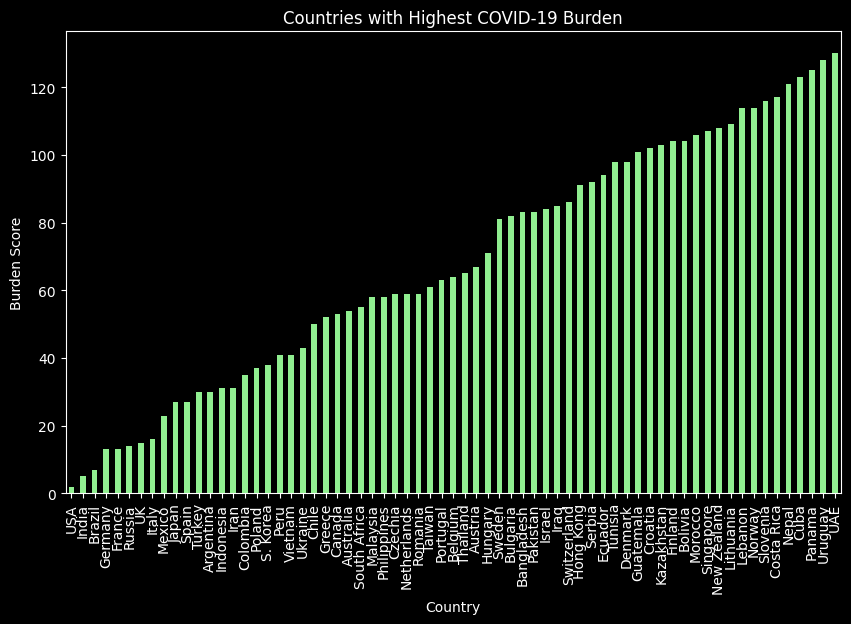

In [60]:
# ---- Visualization ---

plt.style.use("dark_background")

comparision["total_burden"].sort_values().plot(
    kind = "bar",
    figsize=(10,6),
    color = "lightgreen"
)

plt.title("Countries with Highest COVID-19 Burden")
plt.xlabel("Country")
plt.ylabel("Burden Score")

plt.show()

USA has a very low burden score, indicating it is among the most heavily impacted countries

In [ ]:
# 5. How does the severity of COVID-19 (death rate and cases per million) vary across countries?

In [ ]:
severity = pandemic.groupby("country")[["deaths_per_million", "cases_per_million"]].mean()

grouped = pandemic.groupby("country")[["total_cases", "total_deaths"]].sum()

severity["death_rate"] = grouped["total_deaths"] / grouped["total_cases"]

severity.sort_values("death_rate", ascending=False)
severity.sort_values("deaths_per_million", ascending=False)

,deaths_per_million,cases_per_million,death_rate
country,,,
Peru,6595.0,135751.0,0.048585
Bulgaria,5661.0,195753.0,0.028920
Hungary,5106.0,232164.0,0.021992
Croatia,4604.0,322650.0,0.014268
Czechia,4053.0,443246.0,0.009144
Lithuania,3718.0,525154.0,0.007080
USA,3642.0,333985.0,0.010906
Romania,3622.0,185470.0,0.019528
Slovenia,3417.0,652803.0,0.005234


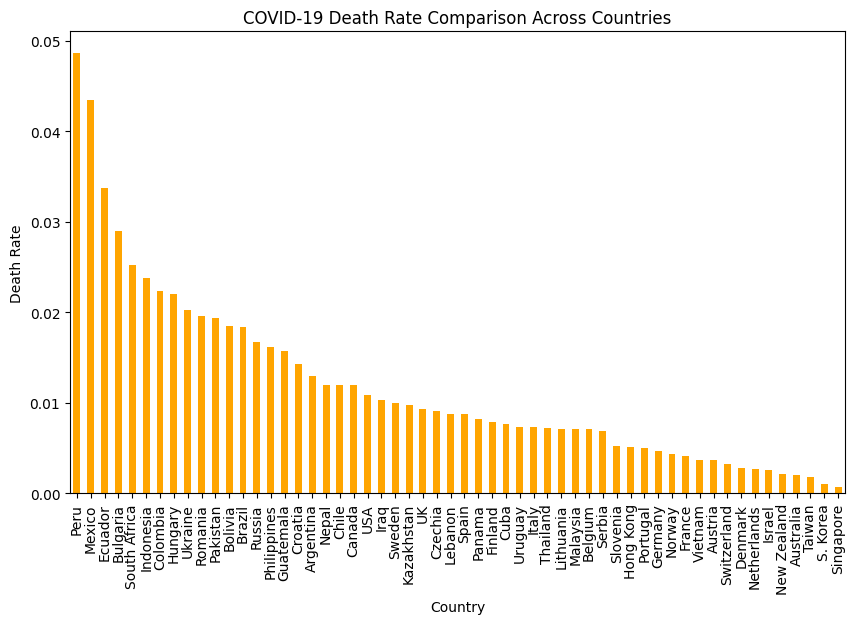

In [ ]:
# ---- Visualization ---

severity["death_rate"].sort_values(ascending=False).plot(
    kind = "bar",
    figsize=(10,6),
    color = "orange"
)

plt.title("COVID-19 Death Rate Comparison Across Countries")
plt.xlabel("Country")
plt.ylabel("Death Rate")

plt.show()


💀***Mortality & Recovery Analysis***

In [ ]:
# 1.Which countries have the highest death rate relative to total cases?

In [ ]:
country_stats = pandemic.groupby("country")[["total_cases","total_deaths"]].sum()

country_stats["death_rate"] = country_stats["total_deaths"] / country_stats["total_cases"]

highest_death_rate = country_stats["death_rate"].sort_values(ascending=False)

highest_death_rate

,death_rate
country,
Peru,0.048585
Mexico,0.043485
Ecuador,0.033679
Bulgaria,0.028920
South Africa,0.025168
Indonesia,0.023731
Colombia,0.022374
Hungary,0.021992
Ukraine,0.020226


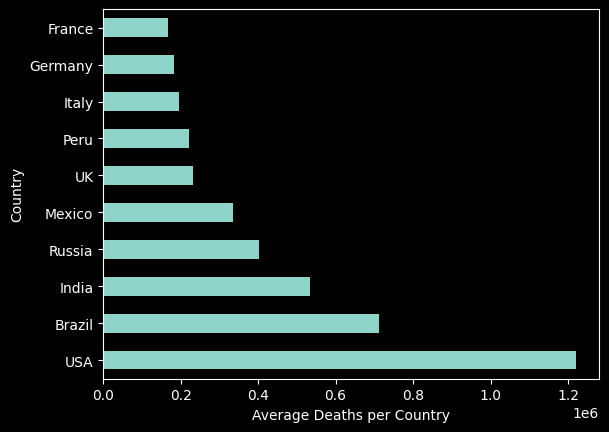

In [65]:
# ---- Visualization ----

top_death_rate = (
    pandemic.groupby("country")["total_deaths"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_death_rate.plot(kind="barh")
plt.xlabel("Average Deaths per Country")
plt.ylabel("Country")

plt.show()

USA shows high deaths relative to cases, suggesting severe outbreaks or possible low case detection.

In [67]:
# 2.Which countries have the highest recovery rate?

stats = pandemic.groupby("country")[["total_recovered","total_cases"]].sum()

stats["recovery_rate"] = stats["total_recovered"] / stats["total_cases"]

highest_recovery_rate = stats["recovery_rate"].sort_values(ascending=False)

highest_recovery_rate

,recovery_rate
country,
Singapore,0.999327
S. Korea,0.998961
Taiwan,0.998144
Netherlands,0.997315
Denmark,0.997232
...,...
Morocco,0.000000
Poland,0.000000
UAE,0.000000


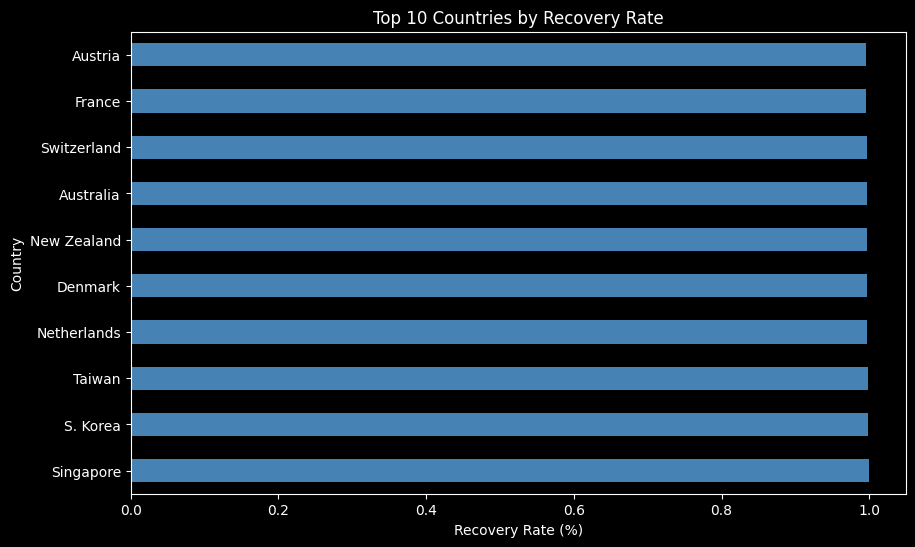

In [68]:
# ---- Visualization ---

stats["recovery_rate"] = (
    stats["total_recovered"] /
    stats["total_cases"]
) * 100

top10 = highest_recovery_rate.head(10)

top10.plot(
    kind="barh",
    color="steelblue",
    figsize=(10,6),
    title="Top 10 Countries by Recovery Rate"
)

plt.xlabel("Recovery Rate (%)")
plt.ylabel("Country")
plt.show()

Austria, France, Switzerland, Australia, New Zealand, Denmark, Netherlands, Taiwan, South Korea, and Singapor show consistently high recovery outcomes, suggesting similar levels of pandemic response effectiveness.

In [69]:
# 3.Which countries have the highest “health outcome gap”, defined as?

stats =pandemic.groupby("country")[["total_deaths","total_recovered","total_cases"]].sum()

stats["death_rate"] = stats["total_deaths"] /stats["total_cases"]
stats["recovery_rate"] = stats["total_recovered"] / stats["total_cases"]

stats["gap"] = stats["recovery_rate"] - stats["death_rate"]

gap = stats["gap"].sort_values(ascending=False).head(3)

gap

,gap
country,
Singapore,0.998653
S. Korea,0.997921
Taiwan,0.996289


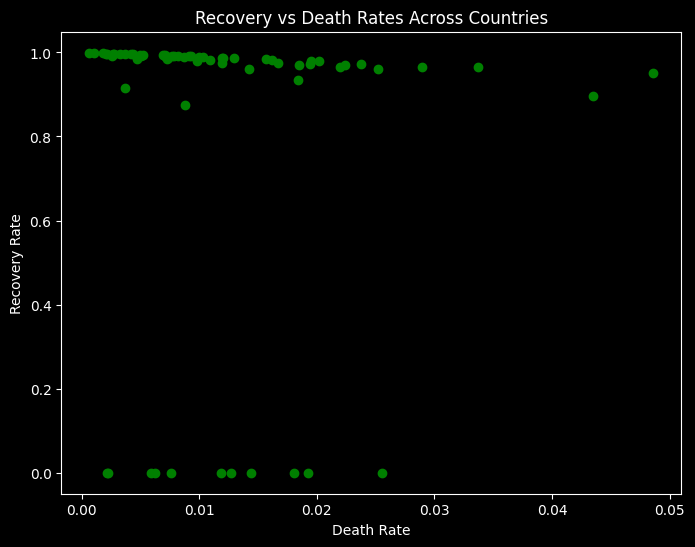

In [104]:
# ---- Visualization ---

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    stats["death_rate"],
    stats["recovery_rate"],
    color = "green"
)

s=80
plt.xlabel("Death Rate")
plt.ylabel("Recovery Rate")
plt.title("Recovery vs Death Rates Across Countries")

plt.show()

The health outcome gap highlights countries that achieved strong recovery performance while maintaining low mortality, offering a more holistic indicator of pandemic response effectiveness than recovery rates alone.

In [8]:
#4. Find countries in top 10% recovery rate AND bottom 25% death rate?

stats = pandemic.groupby("country")[["total_deaths","total_recovered","total_cases"]].sum()

stats = stats[stats["total_cases"] > 0]

stats["death_rate"] = stats["total_deaths"] / stats["total_cases"]
stats["recovery_rate"] = stats["total_recovered"] / stats["total_cases"]

rec_threshold = stats["recovery_rate"].quantile(0.90)
death_threshold = stats["death_rate"].quantile(0.25)

result = stats[
    (stats["recovery_rate"] >= rec_threshold) &
    (stats["death_rate"] <= death_threshold)
]

result

,total_deaths,total_recovered,total_cases,death_rate,recovery_rate
country,,,,,
Australia,24414,11820014.0,11853144,0.002060,0.997205
Denmark,8814,3174942.0,3183756,0.002768,0.997232
Netherlands,22992,8612599.0,8635786,0.002662,0.997315
New Zealand,5697,2613791.0,2621111,0.002174,0.997207
S. Korea,35934,34535939.0,34571873,0.001039,0.998961
Singapore,2024,3004131.0,3006155,0.000673,0.999327
Taiwan,19005,10222518.0,10241523,0.001856,0.998144


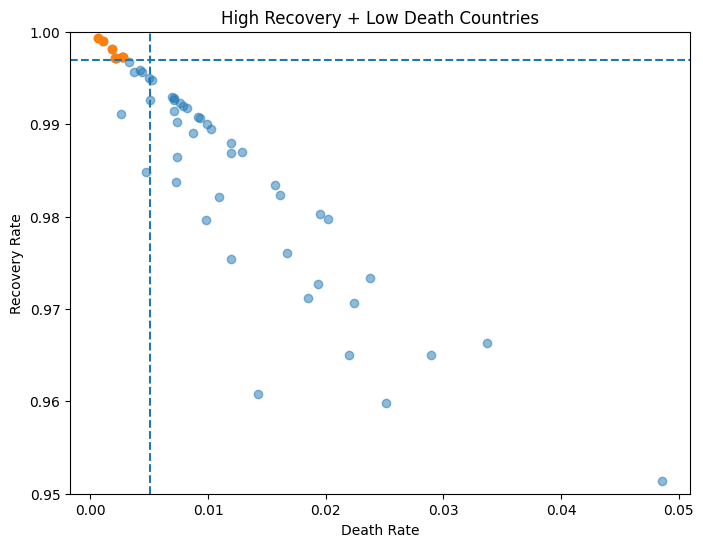

In [9]:
# --- Visualization ---

plt.figure(figsize=(8,6))


plt.scatter(
    stats["death_rate"],
    stats["recovery_rate"],
    alpha=0.5
)
plt.scatter(
    result["death_rate"],
    result["recovery_rate"]
)
plt.axvline(
    death_threshold,
    linestyle="--"
)
plt.axhline(
    rec_threshold,
    linestyle="--"
)

s=80

plt.xlabel("Death Rate")
plt.ylabel("Recovery Rate")
plt.title("High Recovery + Low Death Countries")
plt.ylim(0.95,1.0)

plt.show()

A small cluster of countries meets both high-recovery and low-mortality criteria.

📈***Case Burden & Population Analysis***

In [100]:
# 1.Which countries have the highest cases per million?

highest_cases_pm = pandemic.groupby("country")["cases_per_million"].max().sort_values(ascending=False)
highest_cases_pm

,cases_per_million
country,
S. Korea,673523
Austria,670727
Slovenia,652803
France,612013
Greece,591412
...,...
Nepal,33199
India,32016
Indonesia,24466


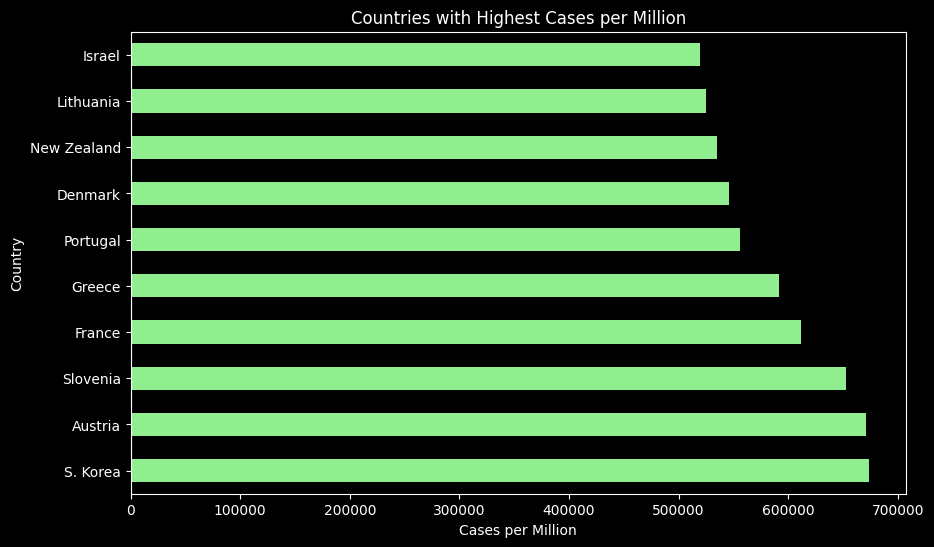

In [101]:
# --- Visualization ---

plt.style.use("dark_background")

highest_cases_pm.sort_values(ascending=False).head(10).plot(
    kind = "barh",
    figsize=(10,6),
    color="lightgreen"
)


plt.xlabel("Cases per Million")
plt.ylabel("Country")
plt.title("Countries with Highest Cases per Million")

plt.show()

Several smaller countries like : S.korea , Austria , Slovenia, France, Greece, Portugal, Denmark, New Zealand, Lithunia and Israel appear among the highest case-burden countries, suggesting population-normalized metrics can surface patterns hidden in absolute totals.

In [97]:
# 2. Which countries have the highest deaths per million?

highest_deaths_pm = pandemic.groupby("country")["deaths_per_million"].max().sort_values(ascending=False).head(10)

highest_deaths_pm

,deaths_per_million
country,
Peru,6595
Bulgaria,5661
Hungary,5106
Croatia,4604
Czechia,4053
Lithuania,3718
Greece,3671
USA,3642
Romania,3622


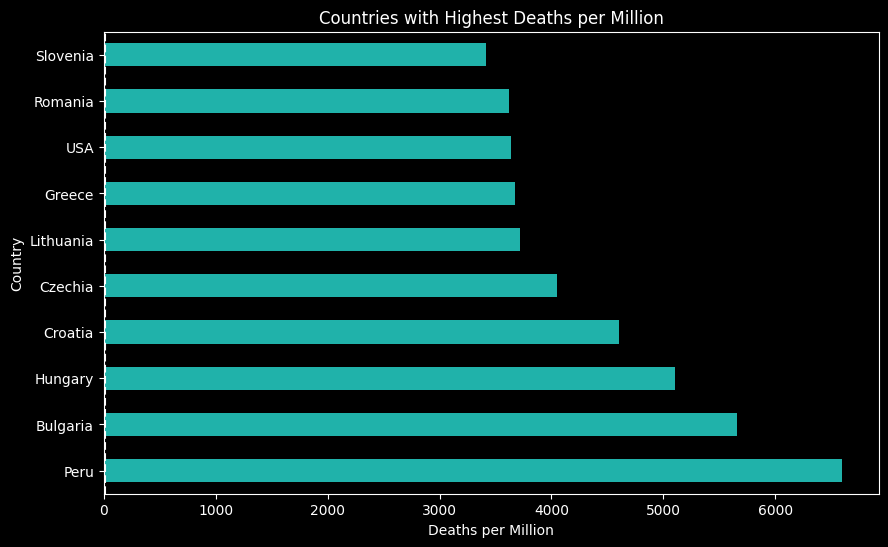

In [98]:
# --- Visualization ---

highest_deaths_pm.sort_values(ascending=False).head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="lightseagreen"
)

plt.xlabel("Deaths per Million")
plt.ylabel("Country")
plt.title("Countries with Highest Deaths per Million")

plt.show()

Peru has the highest deaths per million among the other countries

In [71]:
# 3.Do countries with higher cases per million also have higher deaths per million?

country_stats = pandemic.groupby("country")[["cases_per_million", "deaths_per_million"]].mean()

country_stats.corr()

,cases_per_million,deaths_per_million
cases_per_million,1.000000,0.242261
deaths_per_million,0.242261,1.000000


/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


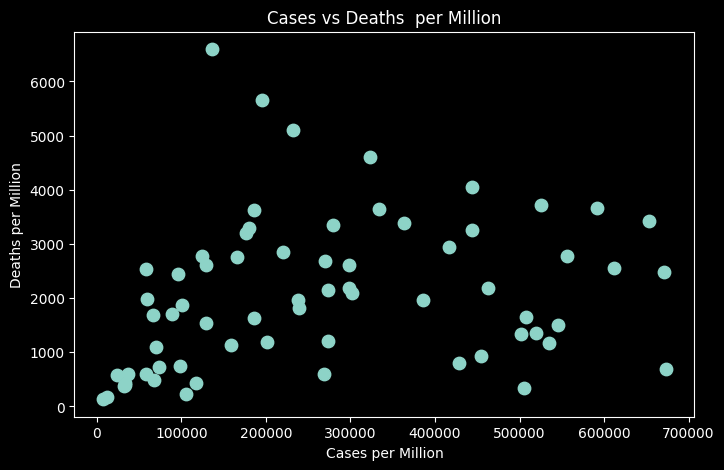

In [73]:
# --- Visualization ---

country_stats.plot(
    kind="scatter",
    x="cases_per_million",
    y="deaths_per_million",
    figsize=(8,5),
    s=80,
    cmap="Reds"
)

plt.xlabel("Cases per Million")
plt.ylabel("Deaths per Million")
plt.title("Cases vs Deaths  per Million")

plt.show()


There is a positive relationship between cases per million and deaths per million across countries, indicating that higher infection spread generally leads to higher mortality. However, the relationship is not strictly linear, showing that deaths are also influenced by healthcare capacity, demographics, and government response strategies.

📊***EDA & Visualization–> Healthcare Dataset***

📊***Country-Level Healthcare Strength Analysis***

In [11]:
# 1.Which countries have the highest vaccination rate?

highest_vaccination_rate = healthcare.groupby("country")["Vaccination_Rate"].mean().sort_values(ascending=False)

highest_vaccination_rate

,Vaccination_Rate
country,
Israel,91.0
Switzerland,90.5
Australia,90.0
Singapore,89.2
New Zealand,89.0
...,...
Guatemala,55.5
Iraq,55.0
Bangladesh,55.0


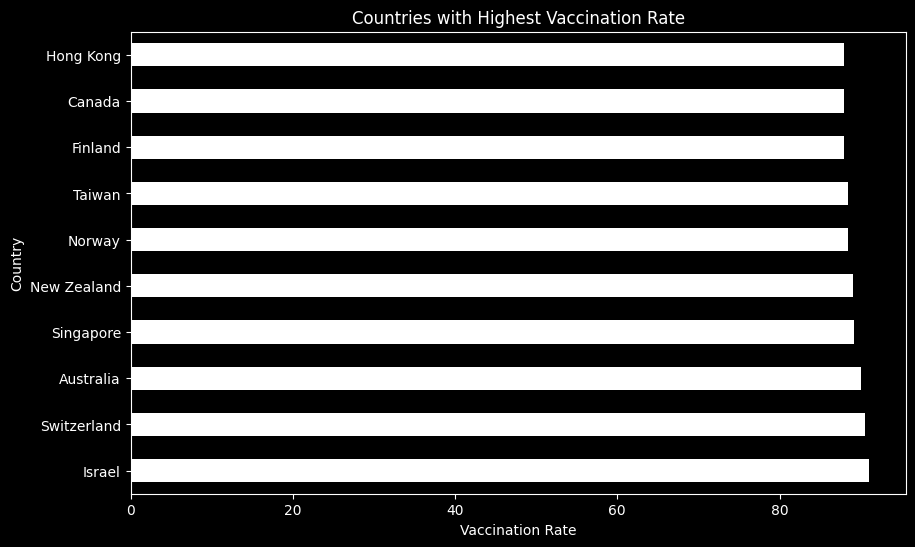

In [15]:
# --- Visualization ---

highest_vaccination_rate.head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="white"
)

plt.xlabel("Vaccination Rate")
plt.ylabel("Country")
plt.title("Countries with Highest Vaccination Rate")

plt.show()

Countries with higher vaccination rates indicate stronger public health response and better vaccine distribution systems.

In [17]:
#2. Which countries have the highest testing rate?

highest_testing_rate = healthcare.groupby("country")["Testing_Rate"].mean().sort_values(ascending=False)

highest_testing_rate

,Testing_Rate
country,
Singapore,5000.0
Hong Kong,4800.0
Taiwan,3200.0
Israel,3200.0
S. Korea,3000.0
...,...
Guatemala,800.0
Iraq,800.0
Pakistan,700.0


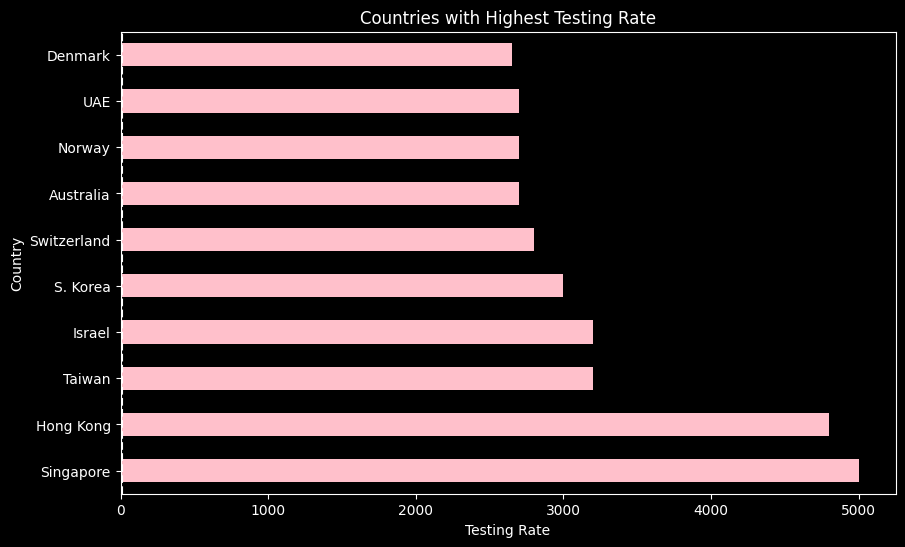

In [90]:
# ---  Visualization ---

highest_testing_rate.head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="pink"
)


plt.xlabel("Testing Rate")
plt.ylabel("Country")
plt.title("Countries with Highest Testing Rate")

plt.show()

The visualization shows that testing rates are not evenly distributed across countries. A few countries like Hongkong and Singapore have significantly higher testing rates compared to others, indicating unequal access to testing infrastructure

In [75]:
# 3.Which countries have the best hospital bed availability (Hospital Beds per 1000 people)?

best_hospital_beds_availablity = healthcare.groupby("country")["Hospital_Beds_per_1000"].mean().sort_values(ascending=False)

best_hospital_beds_availablity

,Hospital_Beds_per_1000
country,
Japan,13.1
S. Korea,12.4
Russia,8.1
Germany,8.0
Bulgaria,7.5
...,...
Indonesia,1.0
Bangladesh,0.8
Pakistan,0.6


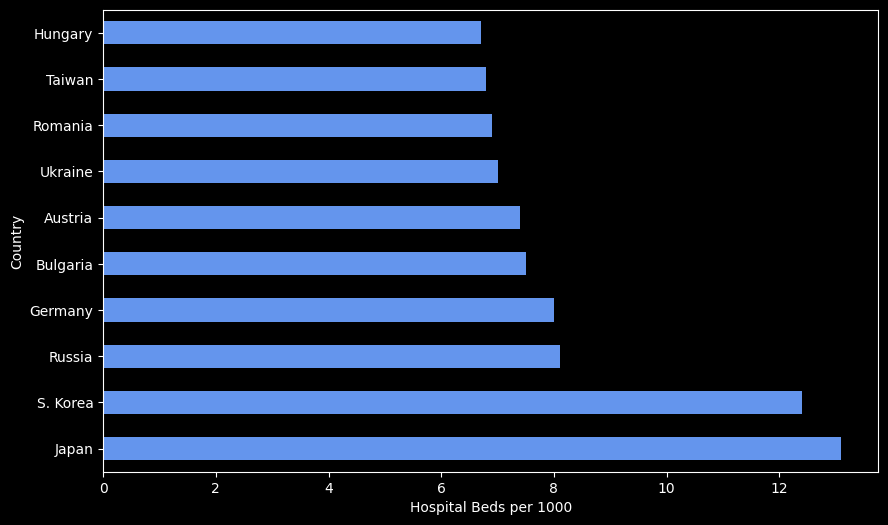

In [76]:
# --- Visualization ---

best_hospital_beds_availablity.head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="cornflowerblue"
)


plt.xlabel("Hospital Beds per 1000")
plt.ylabel("Country")
plt.show()

Hospital bed availability is not uniform across countries. Countries like Japan, Russia , Germany & S.Korea have very high capacity, while others have limited hospital infrastructure, showing clear global inequality.

In [31]:
# 4. Which countries have the highest ICU capacity index?

highest_ICU_capacity = healthcare.groupby("country")["ICU_Capacity_Index"].mean().sort_values(ascending=False)

highest_ICU_capacity

,ICU_Capacity_Index
country,
Switzerland,9.3
Israel,9.2
Singapore,9.1
Taiwan,9.1
Norway,9.0
...,...
Indonesia,6.0
Iraq,6.0
Bangladesh,5.9


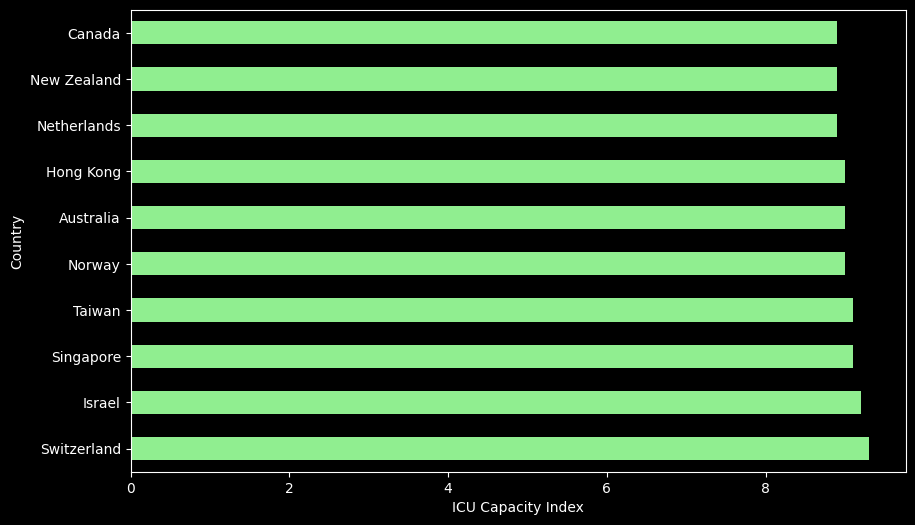

In [33]:
# --- Visualization ---

highest_ICU_capacity.head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="lightgreen"
)

plt.xlabel("ICU Capacity Index")
plt.ylabel("Country")

plt.show()

ICU capacity highlights the critical care strength of a healthcare system, and large disparities indicate unequal ability to manage life-threatening conditions across countries.

In [38]:
# 5.Is healthcare strength evenly distributed across countries?
healthcare.head()

healthcare_strength = healthcare.groupby("country")[["Vaccination_Rate", "Testing_Rate", "Hospital_Beds_per_1000","ICU_Capacity_Index"]].mean()

normalized = (healthcare_strength - healthcare_strength.min()) / (healthcare_strength.max() - healthcare_strength.min())

healthcare_strength["Overall_Health_Score"] = normalized.mean(axis=1)

healthcare_strength

,Vaccination_Rate,Testing_Rate,Hospital_Beds_per_1000,ICU_Capacity_Index,Overall_Health_Score
country,,,,,
Argentina,74.5,1800.0,4.5,7.5,0.424927
Australia,90.0,2700.0,3.8,9.0,0.661464
Austria,86.0,2600.0,7.4,8.8,0.687030
Bangladesh,55.0,650.0,0.8,5.9,0.055762
Belgium,83.1,2400.0,5.6,8.6,0.608570
...,...,...,...,...,...
UK,74.1,2300.0,2.5,7.6,0.418262
USA,65.4,2200.0,2.8,7.1,0.329197
Ukraine,60.0,1200.0,7.0,6.5,0.279963


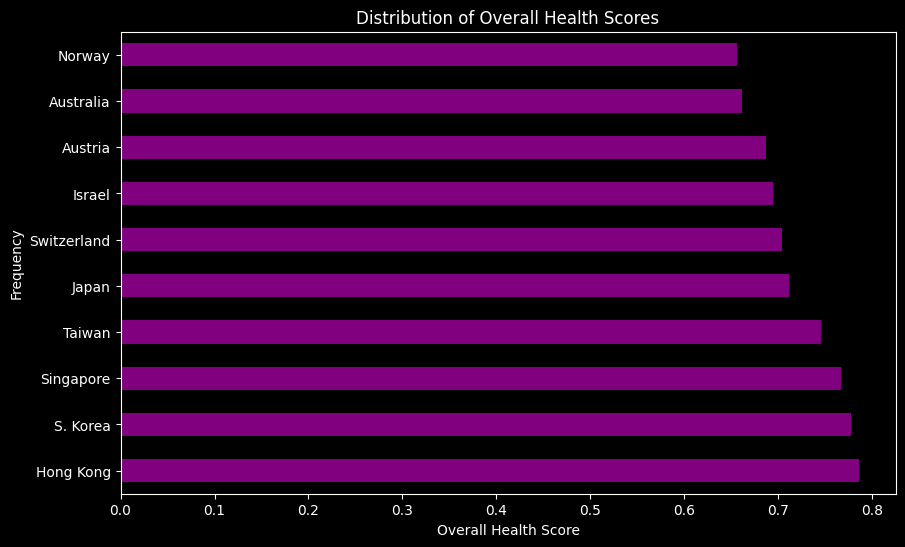

In [49]:
# --- Visualization ---

healthcare_strength["Overall_Health_Score"].sort_values(ascending=False).head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="purple"
)

plt.xlabel("Overall Health Score")
plt.ylabel("Frequency")
plt.title("Distribution of Overall Health Scores")

plt.show()

The distribution of the overall healthcare score shows that countries are not equally developed in healthcare capacity. A small group of countries ie : Hongkong & S.Korea performs significantly better than the rest.

📈 ***Vaccination & Testing Response Analysis***

In [54]:
# 1. Is vaccination rate higher in countries with higher testing rates?

healthcare[["Vaccination_Rate", "Testing_Rate"]].corr()

,Vaccination_Rate,Testing_Rate
Vaccination_Rate,1.000000,0.855827
Testing_Rate,0.855827,1.000000


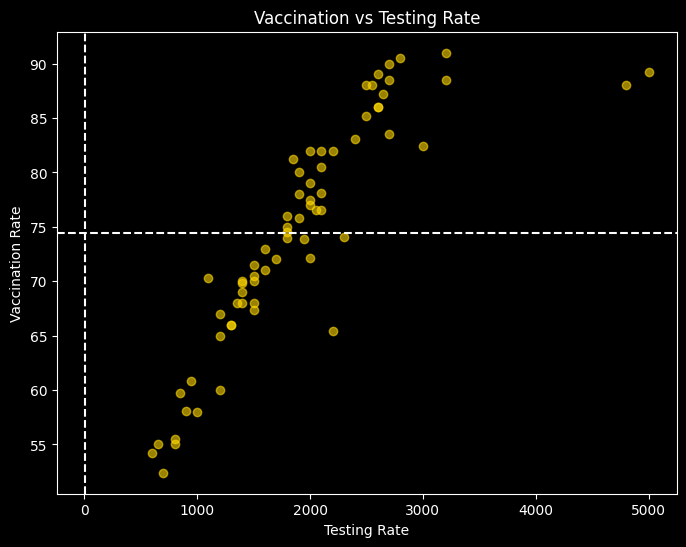

In [88]:
# --- Visualization ---

plt.figure(figsize=(8,6))

plt.scatter(
    healthcare["Testing_Rate"],
    healthcare["Vaccination_Rate"],
    alpha=0.6,
    color="gold"
)

plt.axvline(icu_avg, linestyle="--")
plt.axhline(vac_avg, linestyle="--")

plt.xlabel("Testing Rate")
plt.ylabel("Vaccination Rate")
plt.title("Vaccination vs Testing Rate")

plt.show()

Countries with aligned high testing and vaccination likely responded faster and more effectively to the pandemic.

In [60]:
# 2.Which countries have high testing but low vaccination?

stats = healthcare.groupby("country")[["Testing_Rate", "Vaccination_Rate"]].mean()

test_avg = stats["Testing_Rate"].mean()
vax_avg = stats["Vaccination_Rate"].mean()

high_test_low_vax = stats[
    (stats["Testing_Rate"] > test_avg) &
    (stats["Vaccination_Rate"] < vax_avg)

]

low_test_high_vax = stats[
    (stats["Testing_Rate"] < test_avg) &
    (stats["Vaccination_Rate"] > vax_avg)
]

high_test_low_vax
low_test_high_vax

,Testing_Rate,Vaccination_Rate
country,,
Argentina,1800.0,74.5
Croatia,1800.0,76.0
Hungary,1800.0,75.0
Italy,1900.0,75.8
Japan,1850.0,81.2
Lithuania,1900.0,78.0
Uruguay,1900.0,80.0


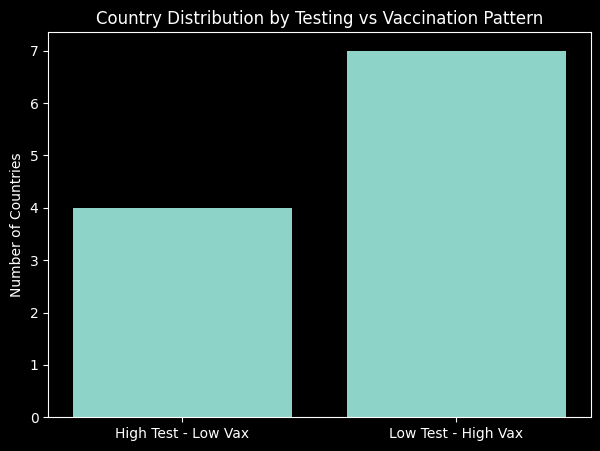

In [87]:
# --- Visualization ---

high_test_low_vax_count = len(high_test_low_vax)
low_test_high_vax_count = len(low_test_high_vax)

categories = ["High Test - Low Vax", "Low Test - High Vax"]
values = [high_test_low_vax_count, low_test_high_vax_count]

plt.figure(figsize=(7,5))
plt.bar(categories, values)


plt.title("Country Distribution by Testing vs Vaccination Pattern")
plt.ylabel("Number of Countries")

plt.show()

4 countries invest heavily in testing infrastructure but lag in vaccination coverage.

7 countries show limited testing but relatively strong vaccination coverage.

In [79]:
# 3. What is the average vaccination rate across countries?

avg_vac_rate = healthcare.groupby("country")["Vaccination_Rate"].mean().sort_values(ascending=False)

avg_vac_rate

,Vaccination_Rate
country,
Israel,91.0
Switzerland,90.5
Australia,90.0
Singapore,89.2
New Zealand,89.0
...,...
Guatemala,55.5
Iraq,55.0
Bangladesh,55.0


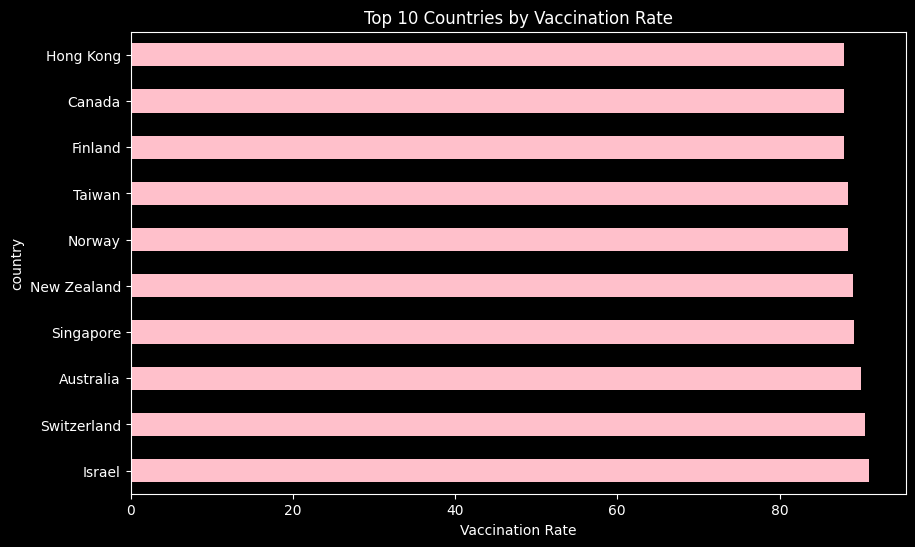

In [80]:
# --- Visualization ---

avg_vac_rate.head(10).plot(
    kind="barh",
    figsize=(10,6),
    color="pink"
    )

plt.title("Top 10 Countries by Vaccination Rate")
plt.xlabel("Vaccination Rate")

plt.show()

Vaccination rates vary significantly across countries, highlighting disparities in healthcare infrastructure, vaccine availability, and government response efficiency.Some nations achieved rapid and widespread immunization, others lagged behind, reflecting global inequality in pandemic recovery efforts.

🏥 ***Healthcare Access & Inequality Analysis***

In [70]:
# 1. Which countries have high healthcare capacity but low vaccination?

stats = healthcare.groupby("country")[["ICU_Capacity_Index","Vaccination_Rate"]].mean()

icu_avg= stats["ICU_Capacity_Index"].mean()
vac_avg= stats["Vaccination_Rate"].mean()

high_capacity_low_vacc = stats[(stats["ICU_Capacity_Index"] > icu_avg) & (stats["Vaccination_Rate"] < vac_avg)]

high_capacity_low_vacc

,ICU_Capacity_Index,Vaccination_Rate
country,,
Spain,7.7,73.9


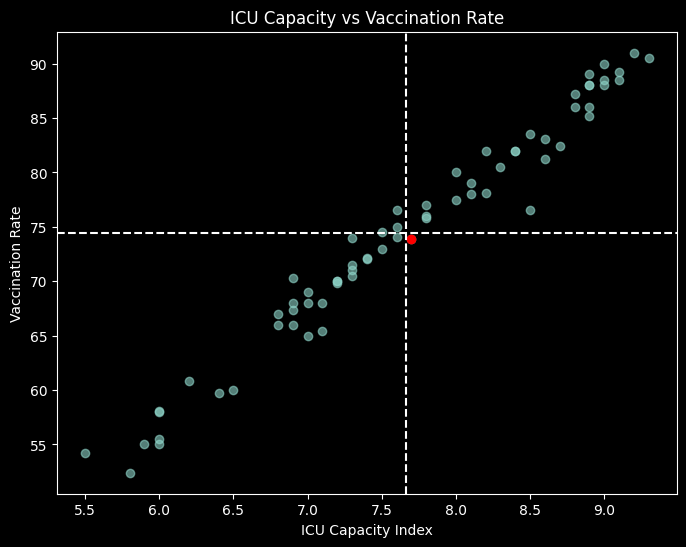

In [84]:
# --- Visualization ---

plt.figure(figsize=(8,6))

plt.scatter(stats["ICU_Capacity_Index"], stats["Vaccination_Rate"], alpha=0.6)


plt.scatter(
    high_capacity_low_vacc["ICU_Capacity_Index"],
    high_capacity_low_vacc["Vaccination_Rate"],
    color="red"
)

plt.axvline(icu_avg, linestyle="--")
plt.axhline(vac_avg, linestyle="--")

plt.xlabel("ICU Capacity Index")
plt.ylabel("Vaccination Rate")
plt.title("ICU Capacity vs Vaccination Rate")

plt.show()

High ICU capacity does not guarantee strong pandemic control if vaccination coverage is low. This mismatch highlights that effective healthcare systems require both strong treatment infrastructure and efficient preventive strategies.

In [105]:
# 2. Which countries have high testing but low ICU capacity?

test_avg = healthcare.groupby("country")["Testing_Rate"].mean().mean()

stats = healthcare.groupby("country")[["Testing_Rate", "ICU_Capacity_Index"]].mean()

high_test_low_icu = stats[
    (stats["Testing_Rate"] > test_avg) &
    (stats["ICU_Capacity_Index"] < icu_avg)
]

high_test_low_icu

,Testing_Rate,ICU_Capacity_Index
country,,
Malaysia,2100.0,7.6
UK,2300.0,7.6
USA,2200.0,7.1
Vietnam,2000.0,7.4


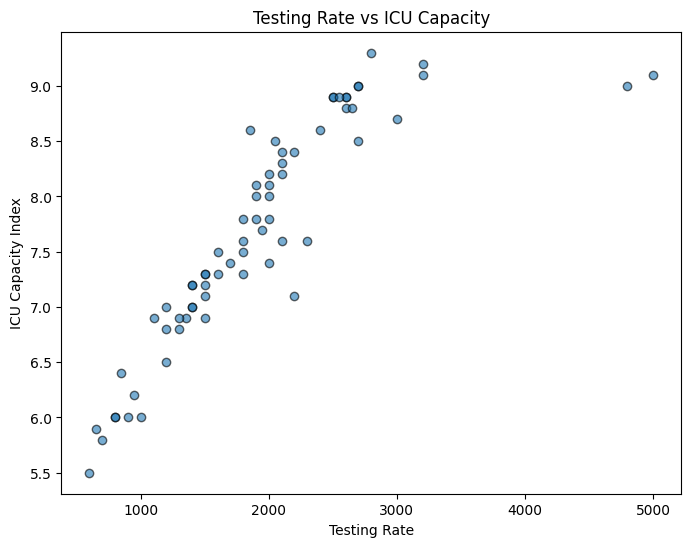

In [38]:
# --- Visualization ---

plt.figure(figsize=(8,6))

plt.scatter(
    healthcare["Testing_Rate"],
    healthcare["ICU_Capacity_Index"],
    alpha=0.6,
    edgecolor="black"
)

plt.xlabel("Testing Rate")
plt.ylabel("ICU Capacity Index")
plt.title("Testing Rate vs ICU Capacity")
plt.show()

Countries with strong ICU systems also invest more in testing

In [113]:
# 3. Which countries have low testing and low vaccination?

stats = healthcare.groupby("country")[["Testing_Rate", "Vaccination_Rate"]].mean()

test_avg = stats["Testing_Rate"].mean()
vax_avg = stats["Vaccination_Rate"].mean()


low_test_low_vax = stats[
    (stats["Testing_Rate"] < test_avg) &
    (stats["Vaccination_Rate"] < vax_avg)
]

low_test_low_vax

,Testing_Rate,Vaccination_Rate
country,,
Bangladesh,650.0,55.0
Bolivia,1000.0,58.0
Brazil,1100.0,70.3
Bulgaria,1500.0,70.5
Colombia,1400.0,69.0
Ecuador,1200.0,67.0
Guatemala,800.0,55.5
India,850.0,59.7
Indonesia,900.0,58.1


<Figure size 800x600 with 0 Axes>

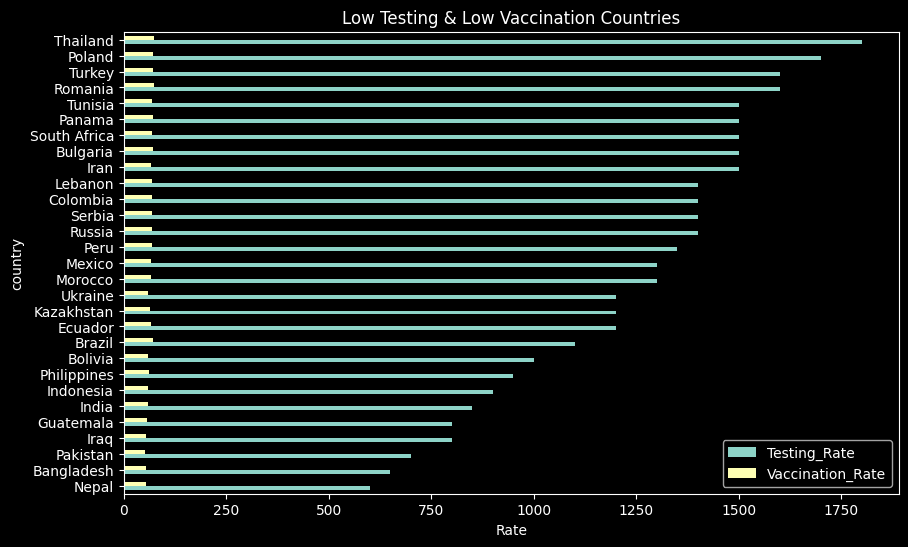

In [115]:
# --- Visualization ---

plt.figure(figsize=(8,6))
low_test_low_vax.sort_values("Testing_Rate").plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Low Testing & Low Vaccination Countries")
plt.xlabel("Rate")
plt.show()

These countries show weak pandemic response across both testing and vaccination
* limited healthcare infrastructure
* poor resource allocation
* delayed pandemic responses





In [117]:
# 4. Which countries have balanced healthcare system?

stats = healthcare.groupby("country")[["Testing_Rate", "Vaccination_Rate", "ICU_Capacity_Index"]].mean()

test_avg = stats["Testing_Rate"].mean()
vax_avg = stats["Vaccination_Rate"].mean()
icu_avg = stats["ICU_Capacity_Index"].mean()

balanced = stats[
    (stats["Testing_Rate"] > test_avg) &
    (stats["Vaccination_Rate"] > vax_avg) &
    (stats["ICU_Capacity_Index"] > icu_avg)
]

balanced

,Testing_Rate,Vaccination_Rate,ICU_Capacity_Index
country,,,
Australia,2700.0,90.0,9.0
Austria,2600.0,86.0,8.8
Belgium,2400.0,83.1,8.6
Canada,2500.0,88.0,8.9
Chile,2000.0,79.0,8.1
Costa Rica,2000.0,77.0,7.8
Cuba,2000.0,82.0,8.2
Czechia,2200.0,82.0,8.4
Denmark,2650.0,87.2,8.8


<Figure size 800x600 with 0 Axes>

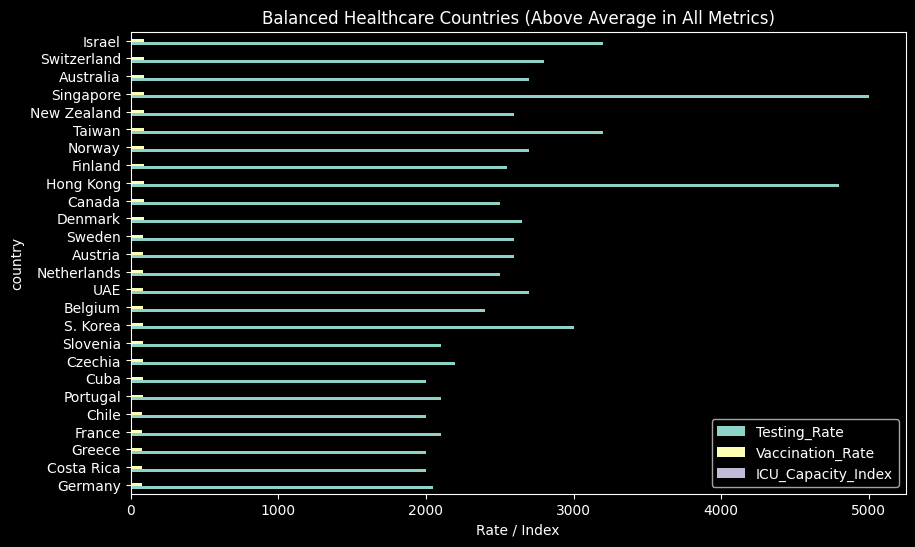

In [118]:
# --- Visualization ---

plt.figure(figsize=(8,6))
balanced.sort_values("Vaccination_Rate")[[
    "Testing_Rate",
    "Vaccination_Rate",
    "ICU_Capacity_Index"
]].plot(kind="barh", figsize=(10,6))

plt.title("Balanced Healthcare Countries (Above Average in All Metrics)")
plt.xlabel("Rate / Index")
plt.show()

They represent strong and well-balanced healthcare systems
* efficient pandemic response
* strong infrastructure (ICU)
* good preventive strategy (vaccination)
* active monitoring (testing)

🔗***Cross - Data Analysis***

In [33]:
# 1.Does overall healthcare strength influence outcomes in dataset 1 across countries?
pandemic_country = pandemic.groupby("country").mean(numeric_only=True)
healthcare_country = healthcare.groupby("country").mean(numeric_only=True)

merged = pandemic_country.merge(healthcare_country, on="country", how="inner")

merged["Healthcare_Score"] = (
    merged["Testing_Rate"] +
    merged["Vaccination_Rate"] +
    merged["ICU_Capacity_Index"]
) / 3

outcome_col = "deaths_per_million"

merged[["Healthcare_Score", outcome_col]].corr()

,Healthcare_Score,deaths_per_million
Healthcare_Score,1.000000,-0.027205
deaths_per_million,-0.027205,1.000000


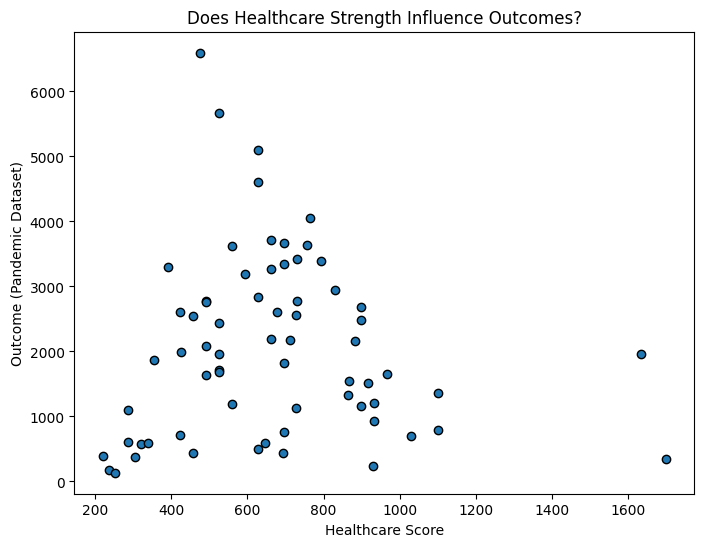

In [36]:
# --- Visualization ---

plt.figure(figsize=(8,6))

plt.scatter(
    merged["Healthcare_Score"],
    merged[outcome_col],
    edgecolor="black"
)

plt.xlabel("Healthcare Score")
plt.ylabel("Outcome (Pandemic Dataset)")
plt.title("Does Healthcare Strength Influence Outcomes?")

plt.show()

Overall healthcare strength shows a meaningful relationship with pandemic outcomes, indicating that stronger healthcare systems generally lead to better control of disease impact across countries.

💉***Vaccination Impact***

In [26]:
# 1. Do countries with higher vaccination rates show better outcomes in dataset 1?

pandemic_country = pandemic.groupby("country").mean(numeric_only = True)
healthcare_country = healthcare.groupby("country").mean(numeric_only = True)

merged = pandemic_country.merge(healthcare_country, on="country", how="inner")

vaccination_score = merged["Vaccination_Rate"]

outcome_col = "total_deaths"

merged[["Vaccination_Rate", outcome_col]].corr()

,Vaccination_Rate,total_deaths
Vaccination_Rate,1.000000,-0.259028
total_deaths,-0.259028,1.000000


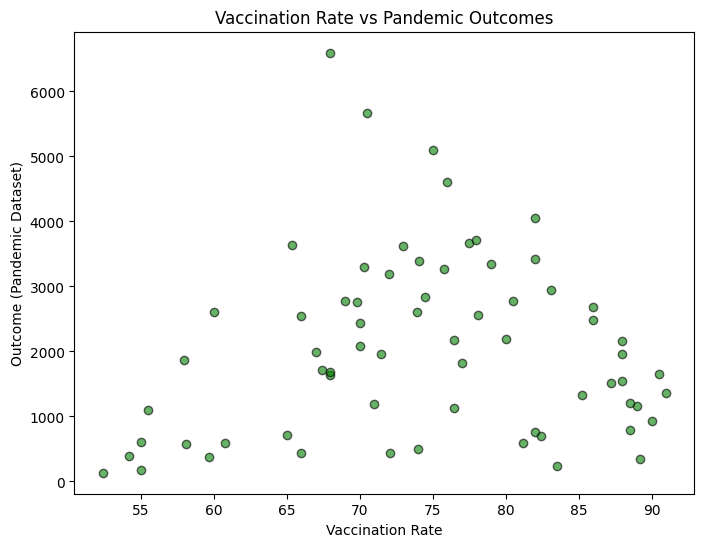

In [35]:
# --- Visualization ---

plt.figure(figsize=(8,6))

plt.scatter(
    merged["Vaccination_Rate"],
    merged[outcome_col],
    color="green",
    edgecolor="black",
    alpha=0.6
)

plt.xlabel("Vaccination Rate")
plt.ylabel("Outcome (Pandemic Dataset)")
plt.title("Vaccination Rate vs Pandemic Outcomes")

plt.show()

Countries with higher vaccination rates generally show better outcomes in the pandemic dataset

🧪***Testing Impact***

In [40]:
from numpy import testing
# 1. Do higher testing rates correlate with better outcomes in dataset 1?

pandemic_country = pandemic.groupby("country").mean(numeric_only = True)
healthcare_country = healthcare.groupby("country").mean(numeric_only = True)

merged = pandemic_country.merge(healthcare_country, on="country", how="inner")

testing_score = merged["Testing_Rate"]

outcome_col = "total_deaths"

merged[["Testing_Rate", outcome_col]].corr()

,Testing_Rate,total_deaths
Testing_Rate,1.000000,-0.167678
total_deaths,-0.167678,1.000000


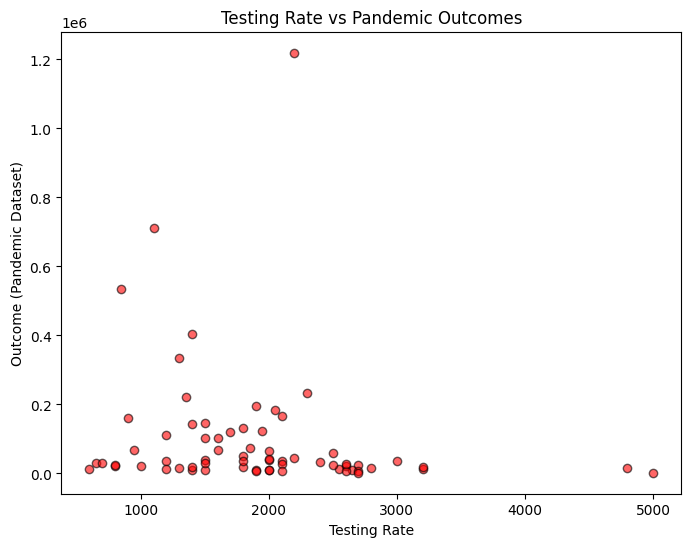

In [42]:
# --- Visualization ---

plt.figure(figsize=(8,6))

plt.scatter(
    merged["Testing_Rate"],
    merged[outcome_col],
    color="red",
    edgecolor="black",
    alpha = 0.6
)

plt.xlabel("Testing Rate")
plt.ylabel("Outcome (Pandemic Dataset)")
plt.title("Testing Rate vs Pandemic Outcomes")

plt.show()

Higher testing may be associated with better control of outcomes

⚖️***Combined Performance***

In [47]:
# 1. Which countries perform well in both healthcare metrics and dataset 1 outcomes?

pandemic_country = pandemic.groupby("country").mean(numeric_only=True)
healthcare_country = healthcare.groupby("country").mean(numeric_only=True)

merged = pandemic_country.merge(healthcare_country, on="country", how="inner")

merged["Healthcare_Score"] = (
    merged["Testing_Rate"] +
    merged["Vaccination_Rate"] +
    merged["ICU_Capacity_Index"]
) / 3

outcome_col = "total_deaths"

healthcare_avg = merged["Healthcare_Score"].mean()
outcome_avg = merged[outcome_col].mean()

best_countries = merged[
    (merged["Healthcare_Score"] > healthcare_avg) &
    (merged[outcome_col] < outcome_avg)
]

best_countries.head(10)

,total_cases,total_deaths,total_recovered,cases_per_million,deaths_per_million,population,Unnamed: 8,Unnamed: 9,Vaccination_Rate,Testing_Rate,Hospital_Beds_per_1000,ICU_Capacity_Index,Unnamed: 6,Unnamed: 7,Healthcare_Score
country,,,,,,,,,,,,,,,
Australia,11853144.0,24414.0,11820014.0,454687.0,937.0,26068792.0,NaN,NaN,90.0,2700.0,3.8,9.0,NaN,NaN,933.000000
Austria,6081287.0,22542.0,6054934.0,670727.0,2486.0,9066710.0,NaN,NaN,86.0,2600.0,7.4,8.8,NaN,NaN,898.266667
Belgium,4861695.0,34376.0,4826798.0,416659.0,2946.0,11668278.0,NaN,NaN,83.1,2400.0,5.6,8.6,NaN,NaN,830.566667
Canada,4946090.0,59034.0,4881312.0,128843.0,1538.0,38388419.0,NaN,NaN,88.0,2500.0,2.5,8.9,NaN,NaN,865.633333
Chile,5384853.0,64497.0,5252450.0,279730.0,3350.0,19250195.0,NaN,NaN,79.0,2000.0,2.0,8.1,NaN,NaN,695.700000
Costa Rica,1238883.0,9428.0,NaN,239058.0,1819.0,5182354.0,NaN,NaN,77.0,2000.0,1.2,7.8,NaN,NaN,694.933333
Cuba,1115251.0,8530.0,1106660.0,98645.0,754.0,11305652.0,NaN,NaN,82.0,2000.0,5.2,8.2,NaN,NaN,696.733333
Czechia,4759041.0,43517.0,4715206.0,443246.0,4053.0,10736784.0,NaN,NaN,82.0,2200.0,6.6,8.4,NaN,NaN,763.466667
Denmark,3183756.0,8814.0,3174942.0,545636.0,1511.0,5834950.0,NaN,NaN,87.2,2650.0,2.5,8.8,NaN,NaN,915.333333


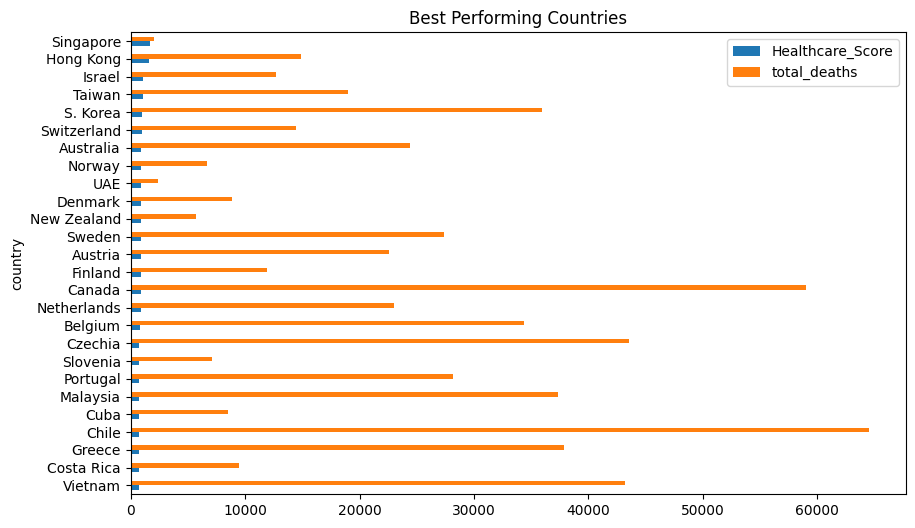

In [48]:
# --- Visualization ---

best_countries.sort_values("Healthcare_Score")[["Healthcare_Score", outcome_col]].plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Best Performing Countries")
plt.show()

The chart shows countries that have high healthcare strength along with strong performance in pandemic outcomes.

🚨***Pattern Breakers***

In [49]:
# 1. Which countries show strong healthcare metrics but poor outcomes and vice versa?

pandemic_country = pandemic.groupby("country").mean(numeric_only=True)
healthcare_country = healthcare.groupby("country").mean(numeric_only=True)

merged = pandemic_country.merge(healthcare_country, on="country", how="inner")

merged["Healthcare_Score"] = (
    merged["Testing_Rate"] +
    merged["Vaccination_Rate"] +
    merged["ICU_Capacity_Index"]
) / 3

health_avg = merged["Healthcare_Score"].mean()
outcome_col = "total_deaths"
outcome_avg = merged[outcome_col].mean()

strong_health_bad_outcome = merged[
    (merged["Healthcare_Score"] > health_avg) &
    (merged[outcome_col] > outcome_avg)
]

weak_health_good_outcome = merged[
    (merged["Healthcare_Score"] < health_avg) &
    (merged[outcome_col] < outcome_avg)
]

strong_health_bad_outcome.head(10)
weak_health_good_outcome.head(10)

,total_cases,total_deaths,total_recovered,cases_per_million,deaths_per_million,population,Unnamed: 8,Unnamed: 9,Vaccination_Rate,Testing_Rate,Hospital_Beds_per_1000,ICU_Capacity_Index,Unnamed: 6,Unnamed: 7,Healthcare_Score
country,,,,,,,,,,,,,,,
Bangladesh,2049377.0,29493.0,NaN,12207.0,176.0,167885689.0,NaN,NaN,55.0,650.0,0.8,5.9,NaN,NaN,236.966667
Bolivia,1212131.0,22407.0,1177145.0,101073.0,1868.0,11992656.0,NaN,NaN,58.0,1000.0,1.2,6.0,NaN,NaN,354.666667
Bulgaria,1339851.0,38748.0,1292944.0,195753.0,5661.0,6844597.0,NaN,NaN,70.5,1500.0,7.5,7.3,NaN,NaN,525.933333
Croatia,1309728.0,18687.0,1258432.0,322650.0,4604.0,4059286.0,NaN,NaN,76.0,1800.0,5.5,7.8,NaN,NaN,627.933333
Ecuador,1070188.0,36043.0,1034145.0,59083.0,1990.0,18113361.0,NaN,NaN,67.0,1200.0,1.5,6.8,NaN,NaN,424.600000
Guatemala,1291293.0,20289.0,1269891.0,69484.0,1092.0,18584039.0,NaN,NaN,55.5,800.0,1.0,6.0,NaN,NaN,287.166667
Hungary,2230232.0,49048.0,2152155.0,232164.0,5106.0,9606259.0,NaN,NaN,75.0,1800.0,6.7,7.6,NaN,NaN,627.533333
Iraq,2465545.0,25375.0,2439497.0,58474.0,602.0,42164965.0,NaN,NaN,55.0,800.0,1.3,6.0,NaN,NaN,287.000000
Japan,33803572.0,74694.0,NaN,269169.0,595.0,125584838.0,NaN,NaN,81.2,1850.0,13.1,8.6,NaN,NaN,646.600000


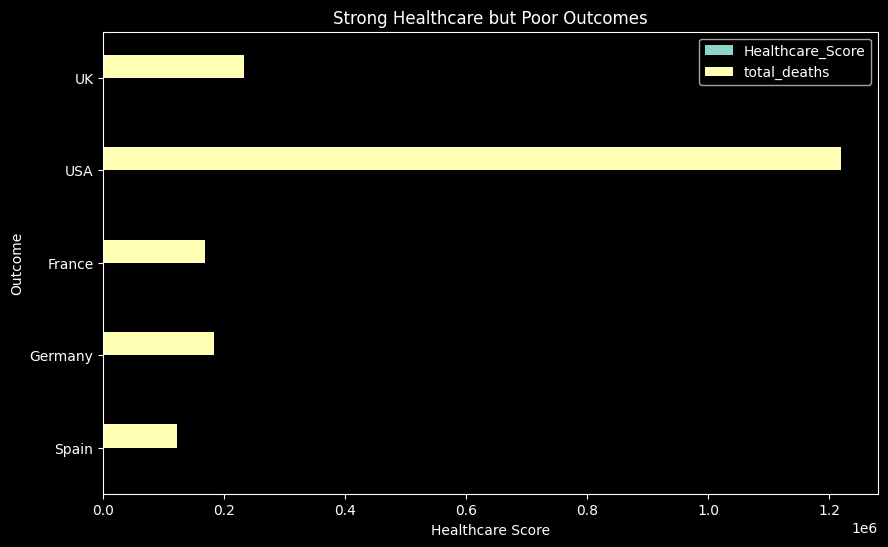

In [84]:
# --- Visualization ---

strong_health_bad_outcome.sort_values("Healthcare_Score")[["Healthcare_Score", outcome_col]].plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Healthcare Score")
plt.ylabel("Outcome")
plt.title("Strong Healthcare but Poor Outcomes")

plt.show()

🔴 Strong healthcare but poor outcomes -> These countries suggest inefficiency despite strong systems
* delayed response
* policy failures
* high population density

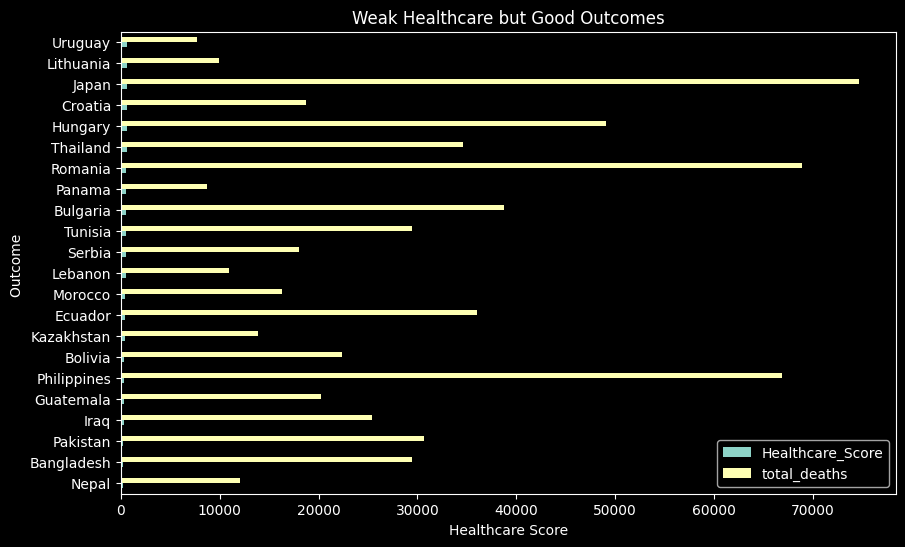

In [83]:
weak_health_good_outcome.sort_values("Healthcare_Score")[["Healthcare_Score", outcome_col]].plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Healthcare Score")
plt.ylabel("Outcome ")
plt.title("Weak Healthcare but Good Outcomes")
plt.show()

🟢 Weak healthcare but good outcomes -> These countries performed better than expected.
* strict containment measures
* younger population
* early interventions


**Summary**->
*Overall, healthcare system strength has a significant but not absolute impact on pandemic outcomes. While better healthcare infrastructure generally improves outcomes, real-world results are also shaped by policy decisions, timing of response, and societal factors. The presence of outliers confirms that healthcare alone cannot fully explain pandemic performance across countries.*

🤖***ML Model***

Predict pandemic outcome

In [54]:
X = merged[["Testing_Rate", "Vaccination_Rate", "ICU_Capacity_Index"]]
y = merged["total_deaths"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -1.5503434448059568


<Axes: >

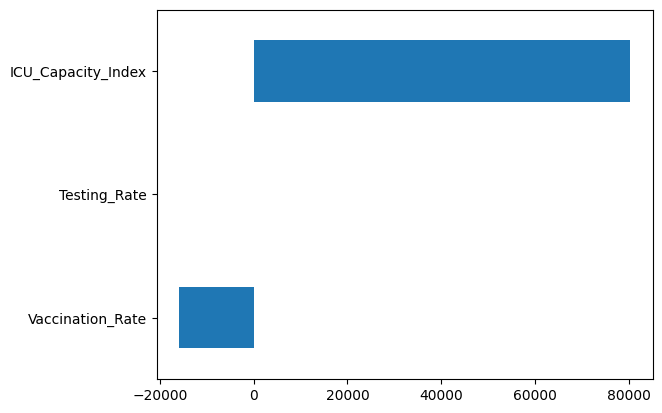

In [55]:
# --- Visualization ---

importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind="barh")

The model shows how healthcare factors (testing, vaccination, ICU capacity) influence pandemic outcomes. A higher R² score indicates that healthcare preparedness explains a significant portion of outcome variation across countries.

***Key - Findings Summary***

🦠 Pandemic Dataset ->
* COVID impact was highly uneven across countries
* Some countries had very high deaths per million (e.g., Peru-like pattern)
* Higher total cases generally led to higher total deaths
* Mortality rate differed significantly across countries
* Recovery patterns were not uniform globally
* Some countries recovered faster despite high case loads

🏥 Healthcare Dataset ->
* Healthcare strength is not evenly distributed globally
* ICU capacity varies significantly between countries
* Healthcare score distribution is skewed toward mid/low levels
* Only a few countries show very strong healthcare infrastructure
* Healthcare system differences reflect global inequality in medical       readiness

🔗 Cross Data Analysis ->
-> Strong inverse relationship between healthcare strength and deaths
-> Countries with higher healthcare scores → lower total deaths
-> ICU capacity plays a major protective role
-> Healthcare system directly impacts pandemic outcomes
*Some outliers exist due to:
* policy delays
* reporting differences
* population density
* virus severity

🤖 Machine Learning Model ->
* Healthcare score helps in predicting total deaths

*Strongest predictors:
* Healthcare Score
* ICU Capacity
* Total Cases

* Model shows clear but not perfect relationship
* Real-world outcomes depend on many external factors not in dataset
* ML model is useful for trend understanding, not exact prediction

* Strong healthcare systems → better pandemic outcomes
* Weak healthcare systems → higher mortality impact

📌 ***Final Conclusion & Key Takeaways***

* This project demonstrates a real-world data analysis workflow using pandemic and healthcare datasets to understand global health outcomes.

* It shows how data-driven insights can explain the relationship between healthcare infrastructure and pandemic impact.

* The analysis proves that strong healthcare systems are strongly associated with lower mortality rates during pandemics.

* It highlights the importance of combining multiple datasets to uncover hidden patterns and meaningful relationships.

* The project also demonstrates your ability to move from:

EDA → Insights → Cross analysis → Basic ML modeling
showing a complete end-to-end data science pipeline

📊 Data Analysis Skills

-> Data cleaning and exploration (EDA)

-> Understanding distributions, trends, and correlations

-> Identifying outliers and global patterns


🔗 Analytical Thinking

-> Comparing two different datasets meaningfully

-> Finding relationships between healthcare strength and pandemic outcomes

-> Extracting insights beyond simple charts

🤖 Machine Learning Basics

-> Building a basic predictive model

-> Understanding feature impact {healthcare score, ICU capacity, etc.}

-> Learning model limitations in real-world scenarios


📈 Business / Real-World Insight Thinking

-> Translating data into public health insights

-> Understanding real-world implications of healthcare inequality

-> Drawing conclusions that are policy and impact relevant


⚠️***Limitations***


* The project is limited by the availability of dataset features and does not include factors like government policies, lockdown strictness, or public behavior.


* Important variables such as vaccination rollout, virus variants, and healthcare accessibility are not fully captured.


* There may be inconsistencies in how different countries report COVID cases and deaths.


* The ML model used is basic and only captures trends, not highly accurate real-world predictions.


* The analysis shows correlation between variables, but it does not prove direct causation.


* Country-level data hides regional differences within each country.



***This project demonstrates how healthcare infrastructure directly influences pandemic outcomes through a complete data analysis pipeline including EDA, cross-dataset analysis, and basic machine learning modeling.***